# Prompt Chaining

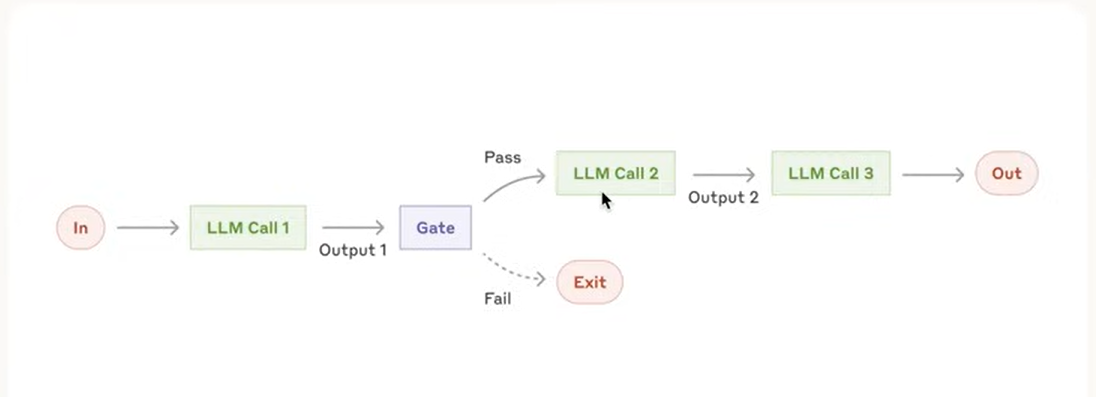

In [13]:
from typing import Optional
from datetime import datetime
from pydantic import BaseModel, Field
from openai import OpenAI
import os
import logging

In [14]:
# Set up logging configuration
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

In [15]:
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
model = "gpt-4o-mini"

In [16]:
# Pydantic Modela

# Extract basic event info and check whether it is an event or not (GATE)
class EventExtraction(BaseModel):
    description: str = Field(description="Raw description of the event")
    is_calendar_event: bool = Field(description="Whether this text describes a calendar event or not")
    confidence_score: float = Field(description="Confidence score between 0 and 1")


# If calendar event then fetch details
class EventDetails(BaseModel):
    name: str = Field(description="Name of the event")
    date: str = Field(description="Date and time of the event. Use ISO 8601 to format this value")
    duration_minutes: int = Field(description="Expected duration in minutes")
    participants: list[str] = Field(description="List of participants")


# Confirmation of the event
class EventConfirmation(BaseModel):
    confirmation_message: str = Field(description="Natural language confirmation message")
    calendar_link: Optional[str] = Field(description="Generated calendar link if applicable")


In [17]:
# Define the functions

# GATE function: whether calendar event or not
def extract_event_info(user_input: str) -> EventExtraction:
    logger.info("Starting event information extraction")
    logger.debug(f"Input Text: {user_input}")

    today = datetime.now()
    date_context = f"Today is {today.strftime('%A, %B %d, %Y')}"
    messages=[
        {
            "role": "system",
            "content": f"{date_context} Analyze if the text describes a calendar event",
        },
        {
            "role": "user",
            "content": user_input,
        }
    ]

    try:
        completion = client.beta.chat.completions.parse(
            model=model,
            messages=messages,
            response_format=EventExtraction,
        )

        result = completion.choices[0].message.parsed
        
        if not isinstance(result, EventExtraction):
            raise TypeError(f"Expected EventExtraction, got {type(result)}")

        logger.info(
            f"Extraction complete - Is calendar event: {result.is_calendar_event}, Confidence: {result.confidence_score:.2f}"
        )
        return result
    except Exception as e:
        logger.error(f"Error in extract_event_info: {str(e)}")
        raise


In [18]:
# Function: Get event details
def parse_event_details(description: str) -> EventDetails:
    logger.info("Starting event details parsing")

    today = datetime.now()
    date_context = f"Today is {today.strftime('%A, %B %d, %Y')}"
    messages=[
        {
            "role": "system",
            "content": f"{date_context} Extract detailed event information. When dates reference 'next Tuesday' or similar relative dates, use this current date as reference.",
        },
        {
            "role": "user",
            "content": description,
        }
    ]

    try:
        completion = client.beta.chat.completions.parse(
            model=model,
            messages=messages,
            response_format=EventDetails,
        )

        result = completion.choices[0].message.parsed
        
        if not isinstance(result, EventDetails):
            raise TypeError(f"Expected EventDetails, got {type(result)}")

        logger.info(
            f"Parsed event details - Name: {result.name}, Date: {result.date}, Duration: {result.duration_minutes}min"
        )
        logger.debug(f"Participants: {', '.join(result.participants)}")
        return result
    except Exception as e:
        logger.error(f"Error in parse_event_details: {str(e)}")
        raise


In [19]:
# Function: Confirmation of the event
def generate_confirmation(event_details: EventDetails) -> EventConfirmation:
    logger.info("Generating Confirmation message")

    # Validate input type
    if not isinstance(event_details, EventDetails):
        raise TypeError(f"Expected EventDetails, got {type(event_details)}: {event_details}")

    today = datetime.now()
    date_context = f"Today is {today.strftime('%A, %B %d, %Y')}"
    messages=[
        {
            "role": "system",
            "content": f"{date_context}Generate a natural confirmation message for the event. Sign off with your name; Sam",
        },
        {
            "role": "user",
            "content": str(event_details.model_dump()),
        }
    ]

    try:
        completion = client.beta.chat.completions.parse(
            model=model,
            messages=messages,
            response_format=EventConfirmation,
        )

        result = completion.choices[0].message.parsed
        
        if not isinstance(result, EventConfirmation):
            raise TypeError(f"Expected EventConfirmation, got {type(result)}")

        logger.info("Confirmation message generated successfully")
        return result
    except Exception as e:
        logger.error(f"Error in generate_confirmation: {str(e)}")
        raise


In [20]:
# Main function: Call all the functions in line

def process_calendar_request(user_input: str) -> Optional[EventConfirmation]:
    logger.info("Processing calendar request")
    logger.debug(f"Raw input: {user_input}")

    # First LLM call: Extract basic info
    initial_extraction = extract_event_info(user_input)

    # Gate Check
    if(not initial_extraction.is_calendar_event or initial_extraction.confidence_score < 0.7):
        logger.warning(
            f"Gate check failed - is_calendar_event: {initial_extraction.is_calendar_event}, confidence: {initial_extraction.confidence_score:.2f}"
        )
        return None
    
    logger.info("Gate check passed, proceeding with event processing")

    # Second LLM call: Get detailed event information
    event_details = parse_event_details(initial_extraction.description)

    # Third LLM call: Generate confirmation
    confirmation = generate_confirmation(event_details)

    logger.info("Calendar request processing completed successfully")
    return confirmation


In [21]:
# Debug: Check API configuration
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    print("WARNING: OPENAI_API_KEY environment variable is not set!")
else:
    print(f"API Key is configured: {api_key[:20]}...")
print(f"Model: {model}")


API Key is configured: sk-proj-ua4nBBL_Q6Qf...
Model: gpt-4o-mini


In [22]:
user_input = "Let's schedule a 1h team meeting next Tuesday at 2pm with Alice and Bob to discuss the project roadmap."

result = process_calendar_request(user_input)
if result:
    print(f"Confirmation: {result.confirmation_message}")
    if result.calendar_link:
        print(f"Calendar Link: {result.calendar_link}")
else:
    print("This doesn't appear to be a calendar event request.")



2026-05-10 17:21:47 - INFO - Processing calendar request
2026-05-10 17:21:47 - INFO - Starting event information extraction
2026-05-10 17:21:50 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-10 17:21:50 - INFO - Extraction complete - Is calendar event: True, Confidence: 0.98
2026-05-10 17:21:50 - INFO - Gate check passed, proceeding with event processing
2026-05-10 17:21:50 - INFO - Starting event details parsing
2026-05-10 17:21:51 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-10 17:21:51 - INFO - Parsed event details - Name: Team Meeting to Discuss Project Roadmap, Date: 2026-05-12T14:00:00, Duration: 60min
2026-05-10 17:21:51 - INFO - Generating Confirmation message
2026-05-10 17:21:53 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-10 17:21:53 - INFO - Confirmation message generated successfully
2026-05-10 17:21:54 - INFO - Calendar r

Confirmation: Hi Team,

This is a quick reminder for our upcoming Team Meeting to Discuss the Project Roadmap scheduled for Tuesday, May 12th at 2:00 PM. The meeting will last for approximately one hour. I look forward to seeing everyone there!

Best, 
Sam


In [23]:
user_input = "Can you send an email to Alice and Bob to discuss the project roadmap?"

result = process_calendar_request(user_input)
if result:
    print(f"Confirmation: {result.confirmation_message}")
    if result.calendar_link:
        print(f"Calendar Link: {result.calendar_link}")
else:
    print("This doesn't appear to be a calendar event request.")

2026-05-10 17:21:54 - INFO - Processing calendar request
2026-05-10 17:21:54 - INFO - Starting event information extraction
2026-05-10 17:21:55 - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2026-05-10 17:21:55 - INFO - Extraction complete - Is calendar event: False, Confidence: 0.85
2026-05-10 17:21:55 - WARNING - Gate check failed - is_calendar_event: False, confidence: 0.85


This doesn't appear to be a calendar event request.
